# 6CS012 - Artificial Intelligence and Machine Learning
## Worksheet 5: End-to-End Image Classification Using CNN


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip /content/drive/MyDrive/FruitinAmazon.zip -d //content/drive/MyDrive

Archive:  /content/drive/MyDrive/FruitinAmazon.zip
  inflating: //content/drive/MyDrive/FruitinAmazon/test/cupuacu/download (5).jpeg  
  inflating: //content/drive/MyDrive/FruitinAmazon/test/acai/images (2).jpeg  
  inflating: //content/drive/MyDrive/FruitinAmazon/test/cupuacu/download (3).jpeg  
  inflating: //content/drive/MyDrive/FruitinAmazon/test/acai/images (16).jpeg  
  inflating: //content/drive/MyDrive/FruitinAmazon/test/pupunha/download (2).jpeg  
  inflating: //content/drive/MyDrive/FruitinAmazon/train/pupunha/images (1).jpeg  
  inflating: //content/drive/MyDrive/FruitinAmazon/test/cupuacu/download (2).jpeg  
  inflating: //content/drive/MyDrive/FruitinAmazon/test/pupunha/download (1).jpeg  
  inflating: //content/drive/MyDrive/FruitinAmazon/train/acai/images (3).jpeg  
  inflating: //content/drive/MyDrive/FruitinAmazon/train/acai/images (4).jpeg  
  inflating: //content/drive/MyDrive/FruitinAmazon/test/graviola/download (1).jpeg  
  inflating: //content/drive/MyDrive/Fruit

In [4]:


import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.19.0
All libraries imported successfully!


## Global Configuration

In [5]:
# CONFIGURATION — update paths as needed


TRAIN_DIR  = "dataset/train"   # Path to training folder
TEST_DIR   = "dataset/test"    # Path to test folder (if separate); else use val split

IMG_HEIGHT     = 128
IMG_WIDTH      = 128
BATCH_SIZE     = 32
VALIDATION_SPLIT = 0.2         # 80% train, 20% validation
SEED           = 123

EPOCHS         = 250
TRAIN_BATCH    = 16            # As specified in Task 4

MODEL_SAVE_PATH = "best_cnn_model.h5"

print("Configuration set.")
print(f"  Image size : {IMG_HEIGHT} x {IMG_WIDTH}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Epochs     : {EPOCHS}")

Configuration set.
  Image size : 128 x 128
  Batch size : 32
  Epochs     : 250


---
## Task 1: Data Understanding and Visualization

### 1a. Load and Visualise One Image per Class

In [7]:
TRAIN_DIR = "/content/drive/MyDrive/FruitinAmazon/train" # Corrected path
# Get list of class directories from the train folder
class_dirs = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

print(f"Number of classes found: {len(class_dirs)}")
print(f"Classes: {class_dirs}")

Number of classes found: 6
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


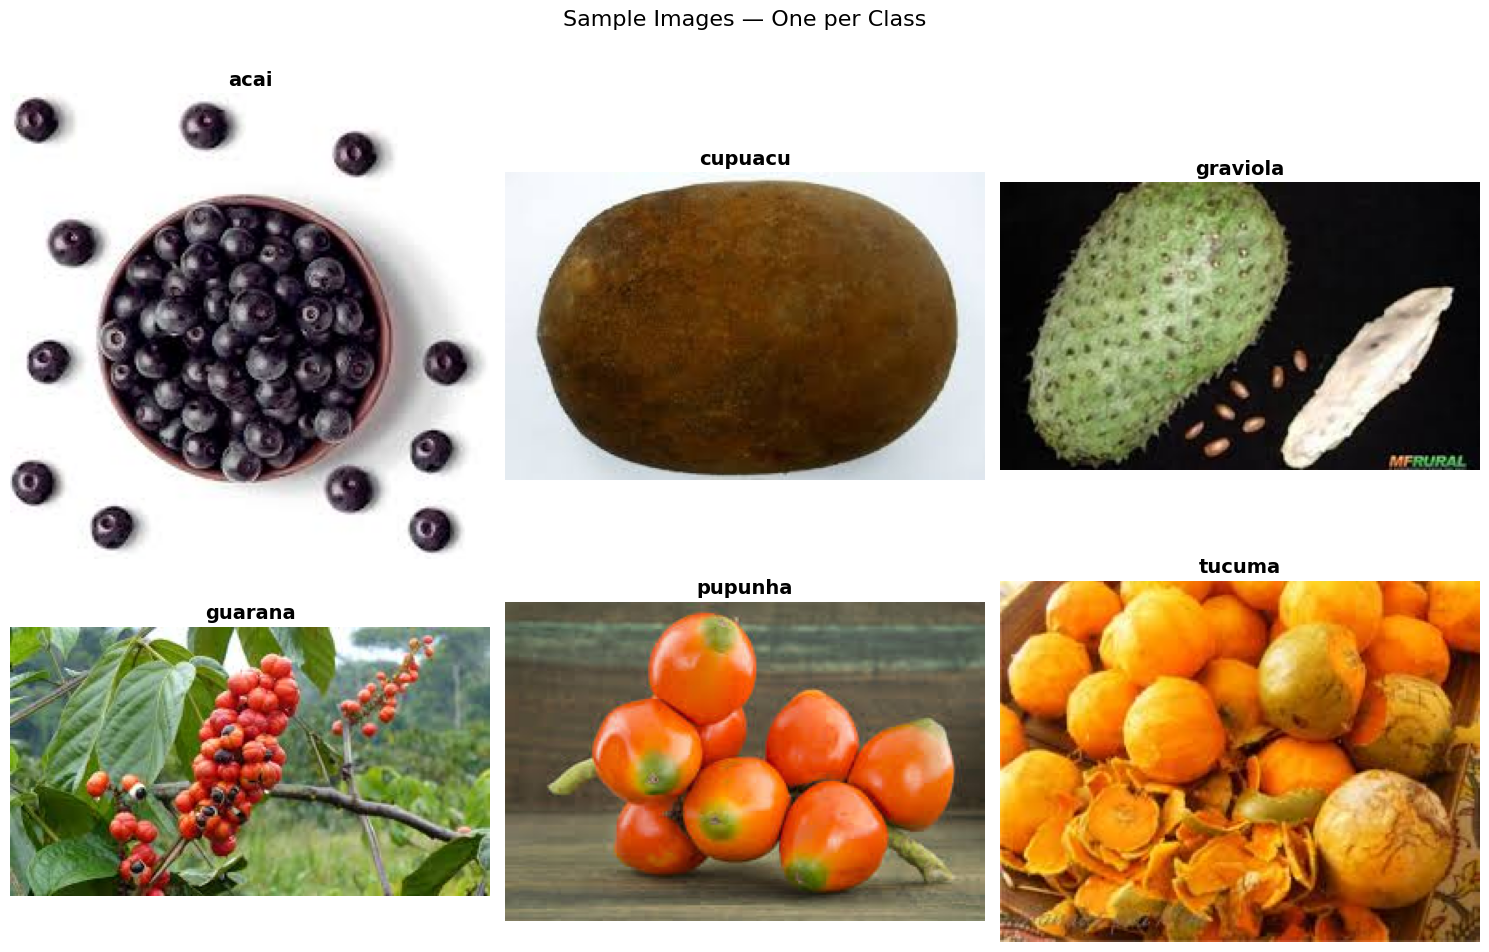

Figure saved as sample_images.png


In [8]:
# Select one random image from each class and display in a 2-row grid

n_classes = len(class_dirs)
cols = (n_classes + 1) // 2          # Number of columns (ceil)
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()                # Flatten for easy indexing

for idx, class_name in enumerate(class_dirs):
    class_path = os.path.join(TRAIN_DIR, class_name)
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    if not images:
        axes[idx].axis("off")
        continue

    # Pick a random image
    random.seed(SEED + idx)
    img_name  = random.choice(images)
    img_path  = os.path.join(class_path, img_name)
    img       = mpimg.imread(img_path)

    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=14, fontweight="bold")
    axes[idx].axis("off")

# Hide any unused axes
for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Sample Images — One per Class", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as sample_images.png")

### 1b. Check for Corrupted Images

In [9]:
corrupted_images = []

for class_name in class_dirs:
    class_path = os.path.join(TRAIN_DIR, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    for img_file in image_files:
        image_path = os.path.join(class_path, img_file)
        try:
            img = Image.open(image_path)
            img.verify()   # Verifies that the file is intact
        except (IOError, SyntaxError):
            print(f"Removed corrupted image: {image_path}")
            os.remove(image_path)
            corrupted_images.append(image_path)

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


---
## Task 2: Loading and Preprocessing Image Data

In [11]:
# Normalisation layer — scales pixel values from [0, 255] → [0, 1]
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# Training
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=TRAIN_BATCH,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
)

# Retrieve class names *before* applying map, as map changes the dataset type
class_names = train_ds.class_names
num_classes = len(class_names)

# Apply normalisation
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=TRAIN_BATCH,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
)

# Apply normalisation
val_ds = val_ds.map(lambda x, y: (rescale(x), y))


print("Class names :", class_names)
print("Num classes :", num_classes)

# Performance optimisation
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6


---
## Task 3: Implement the CNN Architecture

In [12]:
def build_cnn(input_shape, num_classes):
    """
    CNN architecture as specified in Worksheet 5 — Task 3.

    Convolutional Block:
        Conv2D(32, 3x3, same, stride=1) → ReLU → MaxPool(2x2, stride=2)
        Conv2D(32, 3x3, same, stride=1) → ReLU → MaxPool(2x2, stride=2)

    Fully Connected Block:
        Flatten → Dense(128, ReLU) → Dense(64, ReLU) → Dense(num_classes, Softmax)
    """
    model = keras.Sequential(name="Fruit_CNN", layers=[

        # Convolutional Block 1
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding="same",
            strides=(1, 1),
            activation="relu",
            input_shape=input_shape,
            name="conv1",
        ),
        layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(2, 2),
            name="pool1",
        ),

        # Convolutional Block 2
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding="same",
            strides=(1, 1),
            activation="relu",
            name="conv2",
        ),
        layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(2, 2),
            name="pool2",
        ),

        # Fully Connected Block
        layers.Flatten(name="flatten"),
        layers.Dense(128, activation="relu", name="dense_128"),
        layers.Dense(64,  activation="relu", name="dense_64"),
        layers.Dense(num_classes, activation="softmax", name="output"),
    ])
    return model


model = build_cnn(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=num_classes,
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Fruit_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Compile and Train the Model

In [13]:
# Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("Model compiled successfully.")

Model compiled successfully.


In [14]:
# Callbacks

# Save the best model based on validation accuracy
checkpoint_cb = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

# Stop training early if val_loss does not improve for 20 consecutive epochs
early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1,
)

# Train
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
)

print("\nTraining complete.")

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.1469 - loss: 2.8932
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 347ms/step - accuracy: 0.1667 - loss: 2.8649 - val_accuracy: 0.0000e+00 - val_loss: 1.8316
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.1979 - loss: 1.8636
Epoch 2: val_accuracy improved from 0.00000 to 0.83333, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 489ms/step - accuracy: 0.2083 - loss: 1.8199 - val_accuracy: 0.8333 - val_loss: 1.5767
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.4625 - loss: 1.6604
Epoch 3: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 350ms/step - accuracy: 0.4167 - loss: 1.6261 - val_accuracy: 0.5000 - val_loss: 1.5816
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.5628 - loss: 1.4595
Epoch 4: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step - accuracy: 0.5694 - loss: 1.4038 - val_accuracy: 0.5000 - val_loss: 1.4566
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.6844 - loss: 1.1930
Epoch 5: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - accuracy: 0.7083 - loss: 1.0792 - val_accuracy: 0.5000 - val_loss: 1.1384
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.8080 - loss: 0


Epoch 11: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 476ms/step - accuracy: 1.0000 - loss: 0.0538 - val_accuracy: 0.9444 - val_loss: 0.3705
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 1.0000 - loss: 0.0218
Epoch 12: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - accuracy: 1.0000 - loss: 0.0178 - val_accuracy: 0.7778 - val_loss: 0.7175
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 1.0000 - loss: 0.0171
Epoch 13: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step - accuracy: 1.0000 - loss: 0.0149 - val_accuracy: 0.8333 - val_loss: 0.4242
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 1.0000 - loss: 0.0048
Epoch 14: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.8333 - val_loss: 0.3670
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 1.0000 -

### Training & Validation Curves

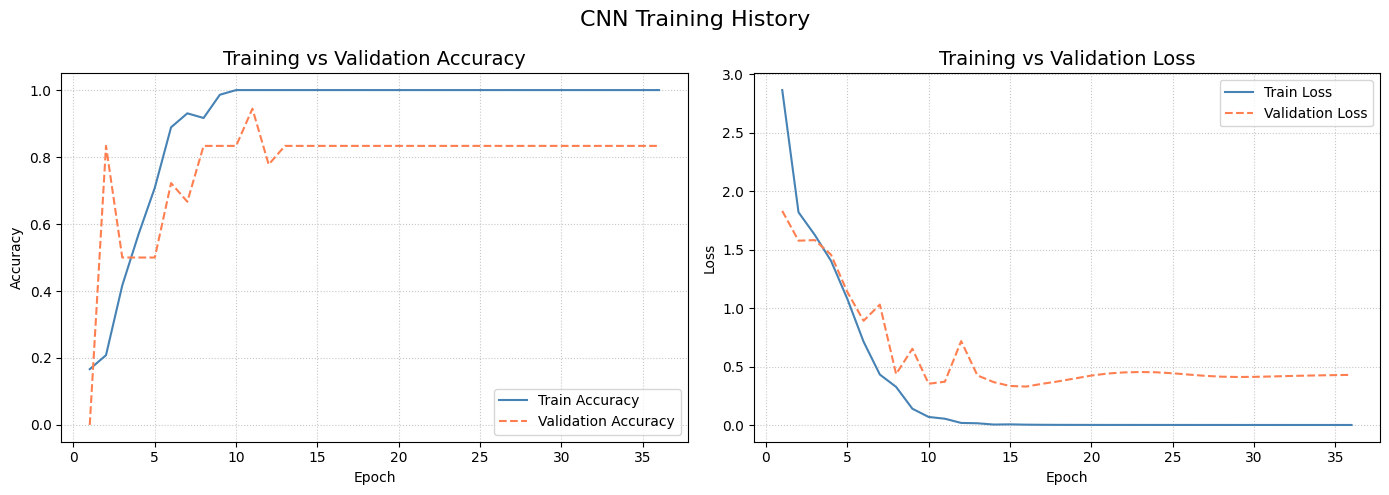

Figure saved as training_history.png


In [15]:
def plot_history(history):
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(epochs_range, acc,     label="Train Accuracy",      color="steelblue")
    axes[0].plot(epochs_range, val_acc, label="Validation Accuracy", color="coral", linestyle="--")
    axes[0].set_title("Training vs Validation Accuracy", fontsize=14)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, linestyle=":", alpha=0.7)

    # Loss
    axes[1].plot(epochs_range, loss,     label="Train Loss",      color="steelblue")
    axes[1].plot(epochs_range, val_loss, label="Validation Loss", color="coral", linestyle="--")
    axes[1].set_title("Training vs Validation Loss", fontsize=14)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, linestyle=":", alpha=0.7)

    plt.suptitle("CNN Training History", fontsize=16)
    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved as training_history.png")


plot_history(history)

---
## Task 5: Evaluate the Model

In [16]:
# Evaluate on the validation set

test_loss, test_acc = model.evaluate(val_ds, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc * 100:.2f}%)")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8333 - loss: 0.3288

Test Loss     : 0.3288
Test Accuracy : 0.8333 (83.33%)


---
## Task 6: Save and Load the Model

In [17]:
# Additionally save the final model explicitly:
model.save(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

Model saved to: best_cnn_model.h5


In [18]:
# Load
loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print("Model loaded successfully.")

# Re-evaluate the loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(val_ds, verbose=1)
print(f"\nLoaded Model — Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model — Test Accuracy : {loaded_acc:.4f} ({loaded_acc * 100:.2f}%)")

Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8333 - loss: 0.3288 

Loaded Model — Test Loss     : 0.3288
Loaded Model — Test Accuracy : 0.8333 (83.33%)


---
## Task 7: Predictions and Classification Report

In [19]:
# Collect all true labels and predictions from val_ds

y_true = []
y_pred_probs = []

for images, labels in val_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)

print(f"Total samples evaluated : {len(y_true)}")
print(f"Unique predicted classes: {np.unique(y_pred)}")

Total samples evaluated : 18
Unique predicted classes: [1 4 5]


In [22]:
# Classification Report
print("Classification Report")
print("=" * 60)
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    labels=np.arange(num_classes), # Explicitly specify all possible labels
    digits=2,
)
print(report)

Classification Report
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       1.00      0.67      0.80         3
      tucuma       0.93      0.87      0.90        15

    accuracy                           0.83        18
   macro avg       0.32      0.26      0.28        18
weighted avg       0.94      0.83      0.88        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

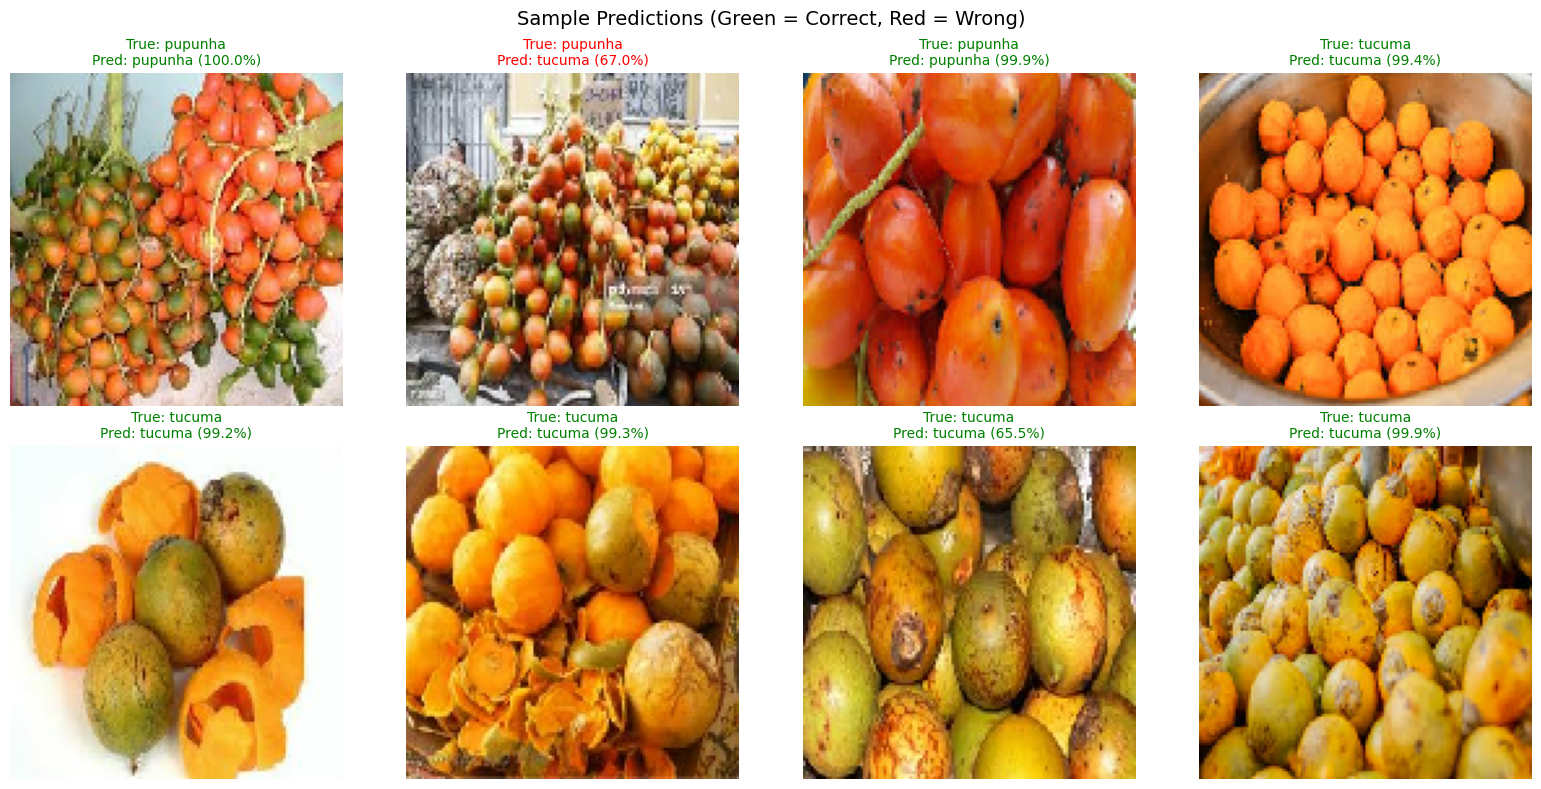

Figure saved as sample_predictions.png


In [23]:
# Visualise predictions on a few sample images

sample_images, sample_labels = next(iter(val_ds))
sample_preds = loaded_model.predict(sample_images, verbose=0)
sample_pred_labels = np.argmax(sample_preds, axis=1)

n_show = min(8, len(sample_images))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_show):
    axes[i].imshow(sample_images[i].numpy())
    true_label  = class_names[sample_labels[i]]
    pred_label  = class_names[sample_pred_labels[i]]
    confidence  = sample_preds[i][sample_pred_labels[i]] * 100
    colour      = "green" if true_label == pred_label else "red"
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
        fontsize=10,
        color=colour,
    )
    axes[i].axis("off")

# Hide unused
for j in range(n_show, len(axes)):
    axes[j].axis("off")

plt.suptitle("Sample Predictions (Green = Correct, Red = Wrong)", fontsize=14)
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as sample_predictions.png")